# 07_Visualizations.ipynb

---

# Decision Boundary

A **decision boundary** is the line (or surface in higher dimensions) that separates different predicted classes.

For KNN, the decision boundary is **not learned as an equation** like Logistic Regression. Instead, it is created by the local arrangement of the training data.

---

## Example Dataset

Imagine two classes:

```text
○ = Class A
● = Class B

        ○     ○

   ○

                 ●

            ●

       ●
```

---

## Decision Boundary with K = 1

Every point is classified based on **only the closest neighbor**.

```text
○ ○ ○│● ● ●
```

The boundary is very irregular because every training point has a strong influence.

Characteristics:

* Very jagged
* Sensitive to noise
* High variance
* Can overfit

---

## Decision Boundary with K = 5

Now each prediction depends on the **5 nearest neighbors**.

```text
○ ○ ○ ○ │ ● ● ●
```

The boundary becomes smoother.

Characteristics:

* Less sensitive to noise
* Better generalization
* Slightly higher bias

---

## Code

```python
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.neighbors import KNeighborsClassifier

X, y = make_moons(
    n_samples=300,
    noise=0.25,
    random_state=42
)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X, y)

x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X[:,0],
    X[:,1],
    c=y
)

plt.title("KNN Decision Boundary")
plt.show()
```

---

## Observation

You will notice:

* The boundary bends around the data.
* It adapts to local neighborhoods.
* It is much more flexible than Logistic Regression.

---

# Effect of Hyperparameters

The three most important hyperparameters are:

* `n_neighbors`
* `weights`
* `metric`

---

## Effect of K

### K = 1

```python
model = KNeighborsClassifier(n_neighbors=1)
```

Expected graph:

```text
Very irregular boundary
```

Characteristics:

* High variance
* Overfits
* Sensitive to noise

---

### K = 5

```python
model = KNeighborsClassifier(n_neighbors=5)
```

Boundary:

```text
Moderately smooth
```

Usually a good starting point.

---

### K = 25

```python
model = KNeighborsClassifier(n_neighbors=25)
```

Boundary:

```text
Very smooth
```

Characteristics:

* High bias
* Underfitting

---

## Visualization Code

```python
for k in [1,5,25]:

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(X,y)

    # Plot decision boundary
```

Run separately for each value of **K** and compare.

---

## Effect of Distance Metric

### Euclidean

```python
metric="euclidean"
```

Distance measured as straight-line distance.

---

### Manhattan

```python
metric="manhattan"
```

Distance measured along horizontal and vertical directions.

Different metrics can slightly change:

* nearest neighbors
* decision boundary
* prediction accuracy

---

## Effect of Weights

### Uniform

```python
weights="uniform"
```

Every neighbor contributes equally.

---

### Distance

```python
weights="distance"
```

Closer neighbors have more influence.

Often improves results when nearby samples are much more representative than farther ones.

---

# Learning Curves

A learning curve shows how the model's performance changes as the amount of training data increases.

---

## Why Use Learning Curves?

They help answer questions such as:

* Is the model overfitting?
* Is the model underfitting?
* Would more training data improve performance?

---

## Code

```python
from sklearn.model_selection import LearningCurveDisplay

LearningCurveDisplay.from_estimator(
    estimator=model,
    X=X,
    y=y,
    cv=5
)

plt.show()
```

---

## Understanding the Graph

The graph contains two curves:

### Training Score

* Accuracy on the training data.

### Cross-Validation Score

* Accuracy on unseen validation data.

---

### Case 1: Good Model

```text
Accuracy

1.0 |------------------
    |                 \
0.9 |                  \
    |                   \
0.8 |____________________\____

        Training Size
```

Training and validation scores become close.

Good generalization.

---

### Case 2: Overfitting

```text
Accuracy

1.0 |-----------------

0.8 |

0.6 |_____________________
```

Training score is much higher than validation score.

Possible fixes:

* Increase K
* Add more training data

---

### Case 3: Underfitting

```text
Accuracy

0.70 ------------------

0.65 ------------------
```

Both curves are low.

Possible fixes:

* Reduce K
* Add informative features

---

# Feature Importance / Coefficients

Unlike Linear Regression or Logistic Regression,

KNN does **not** learn:

* coefficients
* weights
* feature importance

Why?

Because it does not fit an equation.

---

## Comparison

### Linear Regression

Learns:

```text
y = w₁x₁ + w₂x₂ + b
```

Feature importance:

```text
w₁

w₂
```

---

### Decision Tree

Learns:

```text
Feature Importance
```

---

### KNN

Learns nothing.

Stores only:

```text
Training Data
```

Therefore,

```python
model.coef_
```

❌ Does not exist.

---

### What Can We Analyze Instead?

Instead of coefficients, we examine:

* Decision boundaries
* Choice of K
* Distance metric
* Neighbor distances (`kneighbors()`)
* Neighbor indices

Example:

```python
distances, indices = model.kneighbors(X_test)
```

This tells us **which training samples influenced each prediction**.

---

# Common Failure Cases

Even though KNN is simple, there are situations where it performs poorly.

---

## 1. Unscaled Features

Example:

| Feature | Value  |
| ------- | ------ |
| Age     | 25     |
| Salary  | 900000 |

Salary dominates the distance calculation.

### Fix

Always scale features.

```python
StandardScaler()
```

---

## 2. High-Dimensional Data

Suppose:

```text
2 Features
```

Distance differences are meaningful.

Now:

```text
100 Features
```

Almost every point becomes similarly distant.

This is called the **Curse of Dimensionality**.

### Fix

* Feature selection
* PCA
* Dimensionality reduction

---

## 3. Too Small K

Example:

```python
K=1
```

One noisy sample can completely change the prediction.

### Fix

Use cross-validation to choose K.

---

## 4. Too Large K

Example:

```python
K=100
```

Almost the entire dataset votes.

The model ignores local patterns.

### Fix

Reduce K.

---

## 5. Imbalanced Dataset

Example:

```text
Class A

950 samples

Class B

50 samples
```

Most neighbors may belong to Class A, even near Class B samples.

### Fix

* Resampling
* Distance weighting
* Adjust class distribution

---

## 6. Large Dataset

Suppose:

```text
1,000,000 samples
```

Every prediction compares the query point with many stored samples.

Prediction becomes slow.

### Fix

* Approximate nearest neighbor methods
* Different algorithms
* Dimensionality reduction

---

# Summary

## Decision Boundary

* Highly flexible
* Non-linear
* Controlled mainly by **K**

---

## Hyperparameters

Most important:

* `n_neighbors`
* `weights`
* `metric`

---

## Learning Curve

Helps identify:

* Overfitting
* Underfitting
* Whether more data is needed

---

## Feature Importance

KNN has:

* ❌ No coefficients
* ❌ No feature importance
* ✅ Stored training samples
* ✅ Neighbor distances

---

## Common Failure Cases

* Unscaled data
* High-dimensional data
* Wrong K
* Imbalanced classes
* Large datasets

---

## Key Takeaways

* KNN creates **flexible, non-linear decision boundaries** that closely follow the training data.
* The value of **K** directly controls the complexity of the boundary:

  * Small **K** → complex boundary, high variance.
  * Large **K** → smooth boundary, high bias.
* KNN does **not** provide feature coefficients or feature importance because it is a **lazy, instance-based** algorithm.
* Learning curves help diagnose whether KNN is overfitting or underfitting.
* The most common reasons for poor performance are:

  * Missing feature scaling,
  * Choosing an inappropriate value of **K**,
  * High-dimensional data (curse of dimensionality),
  * Large datasets leading to slow predictions.


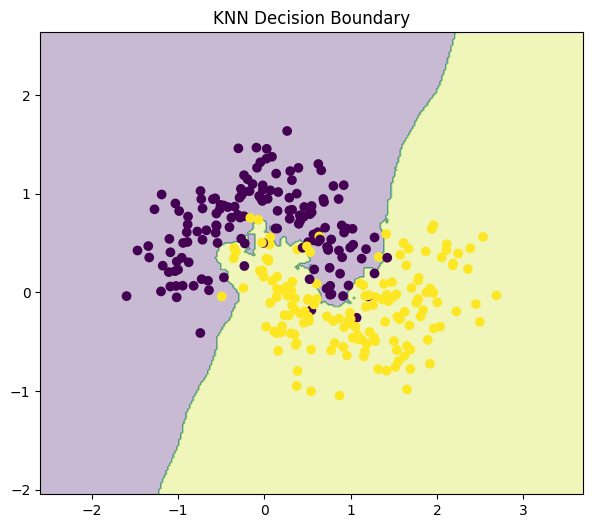

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.neighbors import KNeighborsClassifier

X, y = make_moons(
    n_samples=300,
    noise=0.25,
    random_state=42
)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X, y)

x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X[:,0],
    X[:,1],
    c=y
)

plt.title("KNN Decision Boundary")
plt.show()

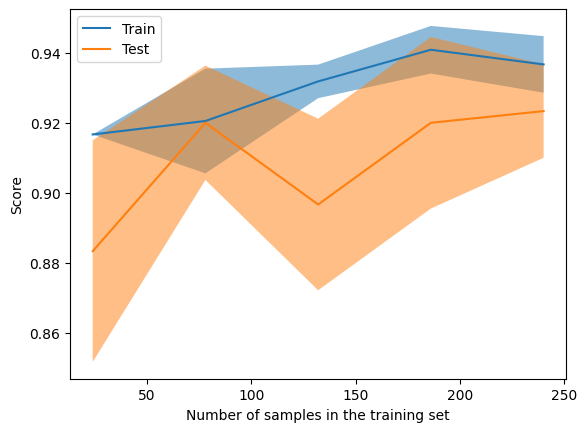

In [2]:
from sklearn.model_selection import LearningCurveDisplay

LearningCurveDisplay.from_estimator(
    estimator=model,
    X=X,
    y=y,
    cv=5
)

plt.show()

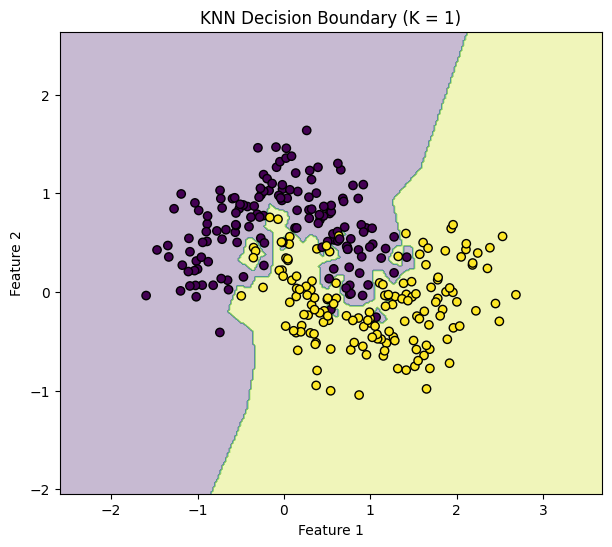

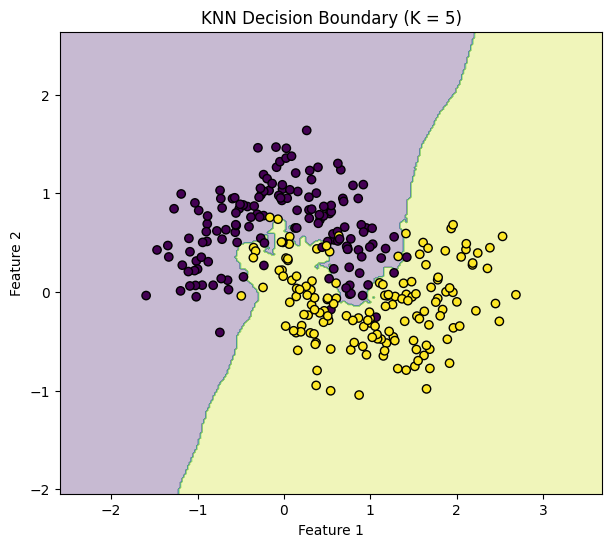

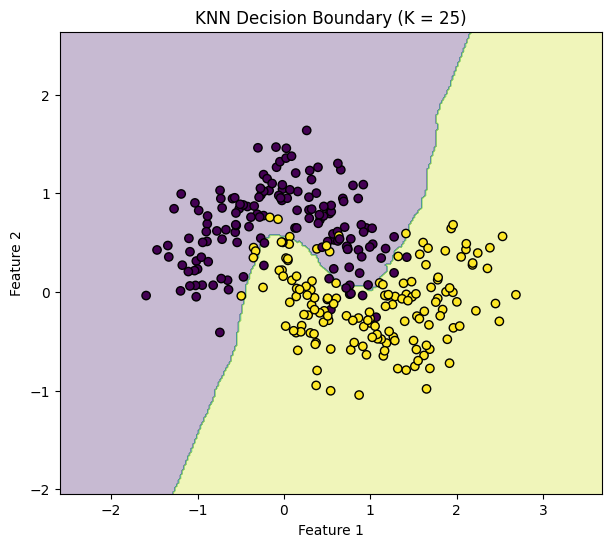

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.neighbors import KNeighborsClassifier

# Generate dataset
X, y = make_moons(
    n_samples=300,
    noise=0.25,
    random_state=42
)

# Plot for different K values
for k in [1, 5, 25]:

    # Create model
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X, y)

    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Predict every point on the grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    plt.figure(figsize=(7, 6))

    plt.contourf(xx, yy, Z, alpha=0.3)

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolors="black"
    )

    plt.title(f"KNN Decision Boundary (K = {k})")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    plt.show()